**Title**: Job Monitoring etc...

**Date**:  TBD

**Description**:  
TBD

### **Requirements**:
1. Access to a Flywheel instance.
3. A Flywheel API key.
2. A Flywheel Project with ideally the dataset used in the [upload-data notebook](https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb).
2. Site Admin Permission?
3. Have some jobs running in your Flywheel Project

<div class="alert alert-block alert-warning" >
    <b>NOTE:</b> This notebook is using a test dataset provided by the <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">upload-data notebook</a>. If you have not uploaded this test dataset yet, we strongly recommend you do so now following steps in <a href="https://gitlab.com/flywheel-io/public/flywheel-tutorials/-/blob/master/python/upload-data-to-a-new-project.ipynb" style="color:black">here</a> before proceeding because this notebook is based on a specific project structure.
</div>

<div class="alert alert-block alert-danger" >
    <b>WARNING:</b> The metadata of the acquisitions in your test project will be updated and new files will be created after running the scripts below. 
</div>

# Install and Import Dependencies

In [ ]:
# Install specific packages required for this notebook
!pip install flywheel-sdk pandas

In [123]:
# Import packages
from getpass import getpass
import logging
import os
from pathlib import Path
import re
import datetime
import pprint
from dateutil.tz import tzutc


from IPython.display import display, Image
import flywheel
import pandas as pd
from tqdm import tqdm
from scipy import stats as st
import matplotlib.pyplot as plt
from scipy.stats import normaltest


In [2]:
# Instantiate a logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
log = logging.getLogger('root')

# Flywheel API Key and Client

Get a API_KEY. More on this at in the Flywheel SDK doc [here](https://flywheel-io.gitlab.io/product/backend/sdk/branches/master/python/getting_started.html#api-key).

In [97]:
API_KEY = getpass('Enter API_KEY here: ')

Enter API_KEY here:  ····································


Instantiate the Flywheel API client

In [98]:
fw = flywheel.Client(API_KEY or os.environ.get('FW_KEY'))

Show Flywheel logging information

In [99]:
log.info('You are now logged in as %s to %s', fw.get_current_user()['email'], fw.get_config()['site']['api_url'])

2020-06-24 20:34:13,921 INFO You are now logged in as huiqiantan@flywheel.io to https://ss.ce.flywheel.io:443/api


***

# Initialize a few value

Define your test Project's Label and let's look for it on your Flywheel instance.

In [7]:
PROJECT_LABEL = input('Please enter your Project Label here: ')

Please enter your Project Label here:  anx_test


# Check Permission

***

In [ ]:
job = fw.get_current_user_jobs()['jobs']

for i in job:
    print(i.gear_info['name'])



In [ ]:
for j in fw.jobs.find('origin.id=huiqiantan@flywheel.io'):
    print(j.gear_info['name'])

In [53]:
gear_name = 'mriqc'

In [ ]:
for j in fw.jobs.find(f'gear_info.name={gear_name}'):
    job = fw.get_job(j.id)
    print(job.gear_info['name'])


100%|██████████| 50/50 [00:04<00:00, 12.47it/s]


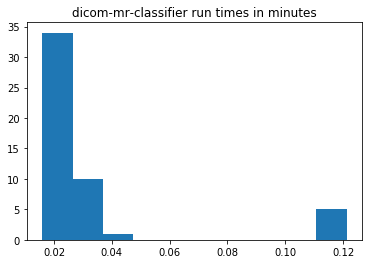

In [55]:
# GET RUN TIMES + PLOT

gear_name = 'dicom-mr-classifier'
created_post = '2020-06-15'
sample_size_max = 50
plot = True

run_times = list()

for j in tqdm(fw.jobs.find(f'gear_info.name={gear_name},state=complete,created>{created_post}', limit=sample_size_max)):
    job = fw.get_job(j.id)
    time_delta = job.transitions.complete - job.transitions.running
    run_times.append(time_delta.total_seconds()/60)

if plot:
    plt.hist(run_times)
    plt.title("{} run times in minutes".format(gear_name))
    plt.show()

In [ ]:
#JOb status
for job in mriqc_job_list:
    job_info = fw.get_job(job)
    log.info('Submitted Job Status: %s', job_info.state)

***

# How to get Job that I launched?

In this section, we will be showing you how to use `get_current_user_jobs` method to get the jobs that you have launched in the past.


Within the Job container, we will be printing the a few attributes within the job such as the `gear_info` that run the job, `state` of the job, and job `id`. 


In [100]:
jobs = fw.get_current_user_jobs()['jobs']

for i, job in enumerate(jobs):
    print(f'Gear Info: {job.gear_info}')
    print(f'Job State: {job.state}')
    print(f'Job ID: {job.id}')
    print()
    if i > 5:
        break
    

Gear Info: {'category': 'converter', 'id': None, 'name': 'curate-bids', 'version': '0.6.8'}
Job State: complete
Job ID: 5eb2ea25bfda5101486aa0af

Gear Info: {'category': 'converter', 'id': None, 'name': 'curate-bids', 'version': '0.6.8'}
Job State: complete
Job ID: 5eb2ea26bfda5101486aa0b0

Gear Info: {'category': 'converter', 'id': None, 'name': 'curate-bids', 'version': '0.6.8'}
Job State: complete
Job ID: 5eb2ea26bfda5101486aa0b1

Gear Info: {'category': 'converter', 'id': None, 'name': 'curate-bids', 'version': '0.6.8'}
Job State: complete
Job ID: 5eb2ea26bfda5101486aa0b2

Gear Info: {'category': 'converter', 'id': None, 'name': 'curate-bids', 'version': '0.6.8'}
Job State: complete
Job ID: 5eb2ea26bfda5101486aa0b3

Gear Info: {'category': 'analysis',
 'id': None,
 'name': 'bids-freesurfer',
 'version': '1.0.2_6.0.1-5'}
Job State: failed
Job ID: 5ec581a9bfda5103816aa099

Gear Info: {'category': 'analysis',
 'id': None,
 'name': 'bids-fmriprep',
 'version': '1.0.12_1.5.10'}
Job Stat

> Expected Output:

```
Gear Info: {'category': 'qa',
 'id': None,
 'name': 'mriqc-demo',
 'version': '0.7.0_0.15.1-hbcd-dev-h'}
Job State: complete
Job ID: 5aee8a5e10a8c402961e70f0

Gear Info: {'category': 'qa',
 'id': None,
 'name': 'mriqc-demo',
 'version': '0.7.0_0.15.1-hbcd-dev-h'}
Job State: complete
Job ID: 5bee77bc10a8c402e21e6f1d
```


<div class="alert alert-block alert-info" style="color: black"><b>INFO:</b> Another method to retrieve jobs is to use <code>get_job()</code>. However, you need to be a Site Admin to run this.</div>

# Find Specific Job Via Job ID

To view a specific job via the Job ID, you can use `get_job_detail`. This will only work for the job you have launched yourself. 

In [ ]:
# Get the latest job that you have launched 
JOB_ID = jobs[0].id

In [44]:
specific_job_detail = fw.get_job_detail(JOB_ID)

In [ ]:
print(f'Gear Info: {specific_job_detail.gear_info}')
print(f'Job State: {specific_job_detail.state}')
print(f'Job ID: {specific_job_detail.id}')

> Expected Output:

```
Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc-demo', 'version': '0.7.0_0.15.1-hbcd-dev-h'}
Job State: complete
Job ID: 5bee77bc10a8c402e21e6f1d
```

***

# Filter Job


In this section, we will showcase how to filter job based on the Gear Name, Date and the State of the Job.

## 1. Gear Name

In [109]:
GEAR_NAME = 'mriqc'

In [144]:
count = 0 

for job in jobs:
    job_gear = job['gear_info']
    if job_gear['name'] == GEAR_NAME and count < 5 :
        print(f'Gear Info: {job.gear_info}')
        print(f'Job State: {job.state}')
        print(f'Job ID: {job.id}')
        count += 1
    elif count > 5:
        break
   

Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc', 'version': '0.7.0_0.15.1'}
Job State: failed
Job ID: 5ec6bb8abfda5103c56aa226
Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc', 'version': '0.7.0_0.15.1'}
Job State: failed
Job ID: 5ec6bb8abfda5103c56aa227
Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc', 'version': '0.7.0_0.15.1'}
Job State: failed
Job ID: 5ec6bb8abfda5103c56aa228
Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc', 'version': '0.7.0_0.15.1'}
Job State: failed
Job ID: 5ec6bb8abfda5103c56aa229
Gear Info: {'category': 'qa', 'id': None, 'name': 'mriqc', 'version': '0.7.0_0.15.1'}
Job State: failed
Job ID: 5ec6bb8abfda5103c56aa22a


## 2. Date

In [133]:
created_by = "2020-06-05"

2020-06-10 00:00:00


In [145]:
count = 0 

for job in jobs:
    if (job.created).strftime("%Y-%m-%d") > created_by and count < 5:
        print(f'Gear Info: {job.gear_info}')
        print(f'Job State: {job.state}')
        print(f'Job ID: {job.id}')
        print()
        count += 1
    elif count > 5:
        break

Gear Info: {'category': 'converter',
 'id': None,
 'name': 'dcm2niix',
 'version': '0.0.1-dev10'}
Job State: complete
Job ID: 5ee80c7c10a8c4025a1e6fbb

Gear Info: {'category': 'converter',
 'id': None,
 'name': 'dcm2niix',
 'version': '0.0.1-dev10'}
Job State: complete
Job ID: 5ee80c8d10a8c4025e1e6faa

Gear Info: {'category': 'converter',
 'id': None,
 'name': 'dcm2niix',
 'version': '0.0.1-dev10'}
Job State: complete
Job ID: 5ee80c9a10a8c402621e6fbc

Gear Info: {'category': 'converter',
 'id': None,
 'name': 'dcm2niix',
 'version': '0.0.1-dev10'}
Job State: complete
Job ID: 5ee80ca910a8c402621e6fc3

Gear Info: {'category': 'converter',
 'id': None,
 'name': 'dcm2niix',
 'version': '0.0.1-dev10'}
Job State: complete
Job ID: 5ee80cb610a8c4025a1e6fc3



In [ ]:
jobs = fw.jobs.find(f'created>{CREATED_POST}')


In [ ]:
for i, job in enumerate(jobs):
    print(job.origin)
    if i > 5:
        break

3. State of the job

In [56]:
jobs = fw.get_current_user_jobs(f'gear_info.name={GEAR_NAME}')

TypeError: get_current_user_jobs() takes 1 positional argument but 2 were given

In [ ]:
for i, jobs in :
    print(job.origin)
    if i > 5:
        break

In [65]:
jobs = fw.get_current_user_jobs()['jobs']

In [ ]:
for job in jobs:
    print(job.gear_info.name)

***

# Cancelling Job

In [34]:
jobs = fw.get_current_user_jobs()['jobs']


In [ ]:
for j in jobs:
    print(j.gear_info.name)
    print(j.state)
    if j.state == 'pending':
        j.update(state='cancelled')

***

# Restarting Job

Job only can be retry once. 

In [36]:
for j in jobs:
    if j.state == 'cancelled' and j.gear_info['name']:
        fw.retry_job(j.id, ignore_state = False )
        

ApiException: (400) Reason: Bad Request
Detail: Can only retry a job that is failed, please use only_failed parameter

***

# Pulling statistics on jobs for a specific gear:
- states
- average run time
- Getting logs for failed job

In [ ]:
# GET RUN TIMES + PLOT

gear_name = 'dicom-mr-classifier'
created_post = '2020-06-15'
sample_size_max = 50
plot = True

run_times = list()

for j in tqdm(fw.jobs.find(f'gear_info.name={gear_name},state=complete,created>{created_post}', limit=sample_size_max)):
    job = fw.get_job(j.id)
    time_delta = job.transitions.complete - job.transitions.running
    run_times.append(time_delta.total_seconds()/60)

if plot:
    plt.hist(run_times)
    plt.title("{} run times in minutes".format(gear_name))
    plt.show()